# Task 3: Domain Generalization
This notebook implements Domain-Adversarial Neural Networks (DAN-DG) and Sharpness-Aware Minimization (SAM) for domain generalization.

In [1]:
!pip install -q scikit-learn pandas matplotlib seaborn tqdm requests

## Setup and Imports

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import copy

def set_seed(seed=6304):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

os.makedirs('data', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)

Using device: cuda


## Dataset Loading (PACS)

In [3]:
# Note: Ensure PACS dataset is available at './data/PACS'
# containing 'photo', 'art_painting', 'cartoon', 'sketch' folders.

class MultiDomainDataset(Dataset):
    def __init__(self, domains, root_dir, transform=None):
        self.datasets = []
        self.domain_indices = []
        self.domain_names = []
        
        for idx, domain in enumerate(domains):
            domain_path = os.path.join(root_dir, domain)
            if not os.path.exists(domain_path):
                print(f"Warning: Path {domain_path} does not exist. Please place PACS dataset in {root_dir}")
                continue
            ds = datasets.ImageFolder(domain_path, transform=transform)
            self.datasets.append(ds)
            self.domain_indices.extend([idx] * len(ds))
            self.domain_names.append(domain)
            
        self.cumulative_sizes = self.cumsum(self.datasets)
        
    @staticmethod
    def cumsum(sequence):
        r, s = [], 0
        for e in sequence:
            l = len(e)
            r.append(l + s)
            s += l
        return r

    def __len__(self):
        return self.cumulative_sizes[-1] if self.cumulative_sizes else 0

    def __getitem__(self, idx):
        if idx < 0:
            if -idx > len(self):
                raise ValueError("absolute value of index should not exceed dataset length")
            idx = len(self) + idx
        dataset_idx = next(i for i, size in enumerate(self.cumulative_sizes) if size > idx)
        if dataset_idx == 0:
            sample_idx = idx
        else:
            sample_idx = idx - self.cumulative_sizes[dataset_idx - 1]
        
        img, label = self.datasets[dataset_idx][sample_idx]
        domain_idx = self.domain_indices[idx]
        return img, label, domain_idx

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def create_splits(dataset, val_split=0.2, seed=6304):
    targets = [dataset.datasets[d].targets[i] for d in range(len(dataset.datasets)) for i in range(len(dataset.datasets[d]))]
    domains = dataset.domain_indices
    stratify_labels = [f"{d}_{c}" for d, c in zip(domains, targets)]
    train_idx, val_idx = train_test_split(
        np.arange(len(dataset)), 
        test_size=val_split, 
        random_state=seed, 
        stratify=stratify_labels
    )
    return Subset(dataset, train_idx), Subset(dataset, val_idx)

class BalancedDomainSampler(torch.utils.data.Sampler):
    def __init__(self, dataset, batch_size_per_domain=8):
        self.dataset = dataset
        self.batch_size_per_domain = batch_size_per_domain
        self.indices_by_domain = {}
        for i, original_idx in enumerate(dataset.indices):
            domain_idx = dataset.dataset.domain_indices[original_idx]
            if domain_idx not in self.indices_by_domain:
                self.indices_by_domain[domain_idx] = []
            self.indices_by_domain[domain_idx].append(i)
            
        self.num_batches = min([len(indices) // batch_size_per_domain for indices in self.indices_by_domain.values()]) if self.indices_by_domain else 0
        self.total_size = self.num_batches * len(self.indices_by_domain) * batch_size_per_domain

    def __iter__(self):
        for domain in self.indices_by_domain:
            np.random.shuffle(self.indices_by_domain[domain])
            
        batches = []
        for b in range(self.num_batches):
            batch = []
            for domain in sorted(self.indices_by_domain.keys()):
                start_idx = b * self.batch_size_per_domain
                end_idx = start_idx + self.batch_size_per_domain
                batch.extend(self.indices_by_domain[domain][start_idx:end_idx])
            batches.append(batch)
            
        np.random.shuffle(batches)
        return iter([idx for batch in batches for idx in batch])

    def __len__(self):
        return self.total_size

source_domains = ['photo', 'art_painting', 'cartoon']
target_domain = ['sketch']
pacs_root = '/kaggle/input/datasets/muhammadibrahim11303/pacs-dataset/Homework3-PACS-master/PACS'

source_dataset_train = MultiDomainDataset(source_domains, pacs_root, transform=train_transform)
source_dataset_val = MultiDomainDataset(source_domains, pacs_root, transform=val_transform)

if len(source_dataset_train) > 0:
    train_subset, _ = create_splits(source_dataset_train)
    _, val_subset = create_splits(source_dataset_val)

    source_val_datasets = {}
    for i, domain in enumerate(source_domains):
        domain_indices = [idx for idx, orig_idx in enumerate(val_subset.indices) if val_subset.dataset.domain_indices[orig_idx] == i]
        source_val_datasets[domain] = Subset(val_subset.dataset, [val_subset.indices[idx] for idx in domain_indices])

    train_sampler = BalancedDomainSampler(train_subset, batch_size_per_domain=8)
    train_loader = DataLoader(train_subset, batch_size=24, sampler=train_sampler, num_workers=0)
else:
    print("PACS dataset not found. Please ensure it is downloaded to ./data/PACS")

## Model and Evaluation Utilities

In [4]:
class ResNet18FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(resnet.children())[:-1])

    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)

class Classifier(nn.Module):
    def __init__(self, in_features=512, num_classes=7):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.fc(x)

def create_model():
    feature_extractor = ResNet18FeatureExtractor()
    classifier = Classifier()
    model = nn.Sequential(feature_extractor, classifier)
    return model

def set_bn_eval(m):
    classname = m.__class__.__name__
    if classname.find('BatchNorm') != -1:
        m.eval()

def evaluate(model, loader):
    model.eval()
    model.apply(set_bn_eval)
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    if len(all_labels) == 0: return 0.0, 0.0
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

def evaluate_domains(model, val_datasets):
    results = {}
    f1_scores = []
    for domain, val_ds in val_datasets.items():
        loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)
        acc, f1 = evaluate(model, loader)
        results[domain] = {'acc': acc, 'f1': f1}
        f1_scores.append(f1)

    results['mean'] = {'acc': np.mean([r['acc'] for r in results.values() if isinstance(r, dict)]),
                       'f1': np.mean(f1_scores)}
    return results

## 1. ERM Baseline

In [5]:
erm_model = create_model().to(device)
erm_checkpoint_path = '/kaggle/input/models/khizaryy/task2-erm/pytorch/default/1/task2_erm.pth'

if os.path.exists(erm_checkpoint_path):
    print(f"Loading ERM checkpoint from {erm_checkpoint_path}...")
    erm_model.load_state_dict(torch.load(erm_checkpoint_path, map_location=device))
    if len(source_dataset_train) > 0:
        erm_val_results = evaluate_domains(erm_model, source_val_datasets)
        print("ERM Source Validation Results:", erm_val_results)
else:
    print(f"WARNING: Task 2 ERM checkpoint not found at {erm_checkpoint_path}.")
    print("Please run Task 2 first to generate this checkpoint.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


Loading ERM checkpoint from /kaggle/input/models/khizaryy/task2-erm/pytorch/default/1/task2_erm.pth...
ERM Source Validation Results: {'photo': {'acc': 0.9579579579579579, 'f1': 0.9505035764142811}, 'art_painting': {'acc': 0.9512195121951219, 'f1': 0.9494098625237167}, 'cartoon': {'acc': 0.9787234042553191, 'f1': 0.9807116706408611}, 'mean': {'acc': np.float64(0.9626336248027996), 'f1': np.float64(0.9602083698596195)}}


## 2. DAN-DG – Pairwise Source-Domain Alignment

In [6]:
def compute_pairwise_distances(x, y):
    x_norm = (x**2).sum(1).view(-1, 1)
    y_norm = (y**2).sum(1).view(1, -1)
    dist = x_norm + y_norm - 2.0 * torch.mm(x, torch.transpose(y, 0, 1))
    return torch.clamp(dist, 0.0, np.inf)

def compute_median_distance(x, y):
    distances = compute_pairwise_distances(x, y)
    return torch.median(distances)

def rbf_kernel(x, y, bandwidths):
    dist = compute_pairwise_distances(x, y)
    kernel_val = torch.zeros_like(dist)
    for bw in bandwidths:
        kernel_val += torch.exp(-dist / bw)
    return kernel_val / len(bandwidths)

def compute_mmd(x, y):
    with torch.no_grad():
        median_dist = compute_median_distance(x, y)
        if median_dist == 0:
            median_dist = 1.0
        bandwidths = [0.5 * median_dist, 1.0 * median_dist, 2.0 * median_dist]

    k_xx = rbf_kernel(x, x, bandwidths)
    k_yy = rbf_kernel(y, y, bandwidths)
    k_xy = rbf_kernel(x, y, bandwidths)

    mmd = k_xx.mean() + k_yy.mean() - 2 * k_xy.mean()
    return mmd

def train_dandg(model, train_loader, val_datasets, epochs=30, lr=1e-4, wd=1e-4, lambda_dg=1.0):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0.0
    patience_counter = 0
    patience = 5
    history = []

    for epoch in range(epochs):
        model.train()
        model.apply(set_bn_eval)

        epoch_loss = 0.0
        epoch_erm_loss = 0.0
        epoch_mmd_loss = 0.0

        for imgs, labels, domain_idxs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)

            features = model[0](imgs)
            outputs = model[1](features)
            loss_erm = criterion(outputs, labels)

            unique_domains = torch.unique(domain_idxs)
            loss_mmd = torch.tensor(0.0).to(device)
            if len(unique_domains) > 1:
                for i in range(len(unique_domains)):
                    for j in range(i+1, len(unique_domains)):
                        d1 = unique_domains[i]
                        d2 = unique_domains[j]
                        mask1 = domain_idxs == d1
                        mask2 = domain_idxs == d2
                        if mask1.sum() > 0 and mask2.sum() > 0:
                            f1 = features[mask1]
                            f2 = features[mask2]
                            loss_mmd += compute_mmd(f1, f2)

            loss = loss_erm + (lambda_dg / 3.0) * loss_mmd

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_erm_loss += loss_erm.item()
            epoch_mmd_loss += loss_mmd.item()

        val_res = evaluate_domains(model, val_datasets)
        mean_f1 = val_res['mean']['f1']

        history.append({'epoch': epoch+1, 'mean_f1': mean_f1, 'loss': epoch_loss/len(train_loader)})
        print(f"Epoch {epoch+1} | Loss: {epoch_loss/len(train_loader):.4f} (ERM: {epoch_erm_loss/len(train_loader):.4f}, MMD: {epoch_mmd_loss/len(train_loader):.4f}) | Val Mean F1: {mean_f1:.4f}")

        if mean_f1 > best_f1:
            best_f1 = mean_f1
            torch.save(model.state_dict(), 'checkpoints/task3_dandg.pth')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(torch.load('checkpoints/task3_dandg.pth'))
    return model, history

if len(source_dataset_train) > 0:
    print("Training DAN-DG...")
    dandg_model = create_model().to(device)
    dandg_model, dandg_history = train_dandg(dandg_model, train_loader, source_val_datasets, lambda_dg=1.0)

Training DAN-DG...


Epoch 1/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.8912 (ERM: 0.7029, MMD: 0.5649) | Val Mean F1: 0.8724


Epoch 2/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.4745 (ERM: 0.3062, MMD: 0.5047) | Val Mean F1: 0.9065


...

Epoch 17 | Loss: 0.2109 (ERM: 0.0621, MMD: 0.4465) | Val Mean F1: 0.9204


Epoch 18/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 18 | Loss: 0.2067 (ERM: 0.0559, MMD: 0.4525) | Val Mean F1: 0.9349


Epoch 19/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 19 | Loss: 0.1959 (ERM: 0.0480, MMD: 0.4436) | Val Mean F1: 0.9468
Early stopping at epoch 19


## 3. SAM – Sharpness-Aware Minimization

In [7]:
def train_sam(model, train_loader, val_datasets, epochs=30, lr=1e-4, wd=1e-4, rho=0.05):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()
    
    best_f1 = 0.0
    patience_counter = 0
    patience = 5
    history = []
    
    for epoch in range(epochs):
        model.train()
        model.apply(set_bn_eval)
        
        epoch_loss = 0.0
        
        for imgs, labels, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            
            epoch_loss += loss.item()
            
            with torch.no_grad():
                grad_norm = torch.sqrt(sum(p.grad.norm()**2 for p in model.parameters() if p.grad is not None))
                epsilon = {}
                for name, p in model.named_parameters():
                    if p.grad is not None:
                        epsilon[name] = rho * p.grad / (grad_norm + 1e-12)
                        p.data.add_(epsilon[name])
                        
            optimizer.zero_grad()
            outputs_pert = model(imgs)
            loss_pert = criterion(outputs_pert, labels)
            loss_pert.backward()
            
            with torch.no_grad():
                for name, p in model.named_parameters():
                    if name in epsilon:
                        p.data.sub_(epsilon[name])
            
            optimizer.step()
            
        val_res = evaluate_domains(model, val_datasets)
        mean_f1 = val_res['mean']['f1']
        
        history.append({'epoch': epoch+1, 'mean_f1': mean_f1, 'loss': epoch_loss/len(train_loader)})
        print(f"Epoch {epoch+1} | Loss: {epoch_loss/len(train_loader):.4f} | Val Mean F1: {mean_f1:.4f}")
        
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            torch.save(model.state_dict(), f'checkpoints/task3_sam_rho_{rho}.pth')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
                
    model.load_state_dict(torch.load(f'checkpoints/task3_sam_rho_{rho}.pth'))
    return model, history

if len(source_dataset_train) > 0:
    print("Training SAM (rho=0.05)...")
    sam_model = create_model().to(device)
    sam_model, sam_history = train_sam(sam_model, train_loader, source_val_datasets, rho=0.05)

Training SAM (rho=0.05)...


Epoch 1/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 1 | Loss: 1.1154 | Val Mean F1: 0.6567


Epoch 2/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.5540 | Val Mean F1: 0.8515


...

Epoch 10 | Loss: 0.0640 | Val Mean F1: 0.9251


Epoch 11/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 11 | Loss: 0.0674 | Val Mean F1: 0.9361


Epoch 12/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 12 | Loss: 0.0623 | Val Mean F1: 0.9237
Early stopping at epoch 12


## 4. Source-Domain Separability and Sharpness Proxy Diagnostics

In [8]:
def compute_separability(model, val_datasets):
    model.eval()
    model.apply(set_bn_eval)
    all_features = []
    all_domains = []

    with torch.no_grad():
        for domain_idx, (domain, val_ds) in enumerate(val_datasets.items()):
            loader = DataLoader(val_ds, batch_size=64, shuffle=False)
            for imgs, labels, _ in loader:
                imgs = imgs.to(device)
                features = model[0](imgs)

                all_features.append(features.cpu().numpy())
                all_domains.extend([domain_idx] * features.shape[0])

    all_features = np.vstack(all_features)
    all_domains = np.array(all_domains)

    X_train, X_test, y_train, y_test = train_test_split(all_features, all_domains, test_size=0.3, random_state=6304, stratify=all_domains)

    clf = LogisticRegression(multi_class='multinomial', C=1.0, solver='lbfgs', max_iter=1000)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    return acc

def compute_sharpness(model, val_datasets, seed=6304):
    model.eval()
    model.apply(set_bn_eval)
    criterion = nn.CrossEntropyLoss()

    batch_imgs = []
    batch_labels = []

    for domain, val_ds in val_datasets.items():
        rng = np.random.RandomState(seed)
        indices = rng.choice(len(val_ds), 32, replace=False)
        for idx in indices:
            img, label, _ = val_ds[idx]
            batch_imgs.append(img)
            batch_labels.append(label)

    batch_imgs = torch.stack(batch_imgs).to(device)
    batch_labels = torch.tensor(batch_labels).to(device)

    model.zero_grad()
    outputs = model(batch_imgs)
    loss = criterion(outputs, batch_labels)
    loss.backward()

    rho = 0.05
    grad_norm = torch.sqrt(sum(p.grad.norm()**2 for p in model.parameters() if p.grad is not None))
    epsilon = {}
    with torch.no_grad():
        for name, p in model.named_parameters():
            if p.grad is not None:
                epsilon[name] = rho * p.grad / (grad_norm + 1e-12)
                p.data.add_(epsilon[name])

    model.zero_grad()
    with torch.no_grad():
        outputs_pert = model(batch_imgs)
        loss_pert = criterion(outputs_pert, batch_labels)

    delta_sharp = loss_pert.item() - loss.item()

    with torch.no_grad():
        for name, p in model.named_parameters():
            if name in epsilon:
                p.data.sub_(epsilon[name])

    return delta_sharp

if len(source_dataset_train) > 0:
    diagnostics = []

    print("Computing diagnostics for ERM...")
    if os.path.exists(erm_checkpoint_path):
        erm_sep = compute_separability(erm_model, source_val_datasets)
        erm_sharp = compute_sharpness(erm_model, source_val_datasets)
        diagnostics.append({'Model': 'ERM', 'Separability': erm_sep, 'Sharpness (Delta L)': erm_sharp})

    print("Computing diagnostics for DAN-DG...")
    dandg_sep = compute_separability(dandg_model, source_val_datasets)
    dandg_sharp = compute_sharpness(dandg_model, source_val_datasets)
    diagnostics.append({'Model': 'DAN-DG', 'Separability': dandg_sep, 'Sharpness (Delta L)': dandg_sharp})

    print("Computing diagnostics for SAM...")
    sam_sep = compute_separability(sam_model, source_val_datasets)
    sam_sharp = compute_sharpness(sam_model, source_val_datasets)
    diagnostics.append({'Model': 'SAM', 'Separability': sam_sep, 'Sharpness (Delta L)': sam_sharp})

    diag_df = pd.DataFrame(diagnostics)
    print(diag_df)
    diag_df.to_csv('results/task3_diagnostics.csv', index=False)

Computing diagnostics for ERM...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Computing diagnostics for DAN-DG...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Computing diagnostics for SAM...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


    Model  Separability  Sharpness (Delta L)
0     ERM      0.890110             0.379443
1  DAN-DG      0.736264             0.249425
2     SAM      0.879121             0.154770


## 5. Controlled Design Study: SAM with varying ρ

Training SAM (rho=0.01)...


Epoch 1/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.6904 | Val Mean F1: 0.9033


Epoch 2/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.2992 | Val Mean F1: 0.8992


...

Epoch 5 | Loss: 1.9210 | Val Mean F1: 0.0507


Epoch 6/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 6 | Loss: 1.8917 | Val Mean F1: 0.0507


Epoch 7/30:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 7 | Loss: 1.8307 | Val Mean F1: 0.0575
Early stopping at epoch 7
    rho  best_val_f1
0  0.01     0.935019
1  0.05     0.943218
2  0.10     0.061390


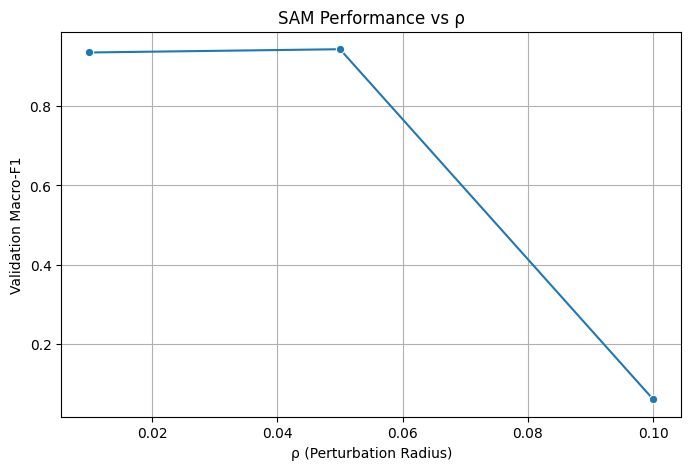

In [9]:
rho_values = [0.01, 0.05, 0.1]
controlled_results = []

if len(source_dataset_train) > 0:
    for r in rho_values:
        if r == 0.05:
            sam_model_r = sam_model
            history_r = sam_history
        else:
            print(f"Training SAM (rho={r})...")
            sam_model_r = create_model().to(device)
            sam_model_r, history_r = train_sam(sam_model_r, train_loader, source_val_datasets, rho=r)
            
        best_val_f1 = max([h['mean_f1'] for h in history_r])
        controlled_results.append({'rho': r, 'best_val_f1': best_val_f1})
        
    study_df = pd.DataFrame(controlled_results)
    print(study_df)
    study_df.to_csv('results/task3_controlled_study.csv', index=False)
    
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=study_df, x='rho', y='best_val_f1', marker='o')
    plt.title('SAM Performance vs ρ')
    plt.xlabel('ρ (Perturbation Radius)')
    plt.ylabel('Validation Macro-F1')
    plt.grid(True)
    plt.savefig('figures/task3_controlled_study.png')
    plt.show()

## 6. Final Evaluation on Target Domain (Sketch)

            Model  Sketch_Acc  Sketch_F1  Delta_F1_from_ERM
0             ERM    0.552049   0.553797           0.000000
1          DAN-DG    0.808094   0.811862           0.258065
2  SAM (rho=0.05)    0.740392   0.762355           0.208557


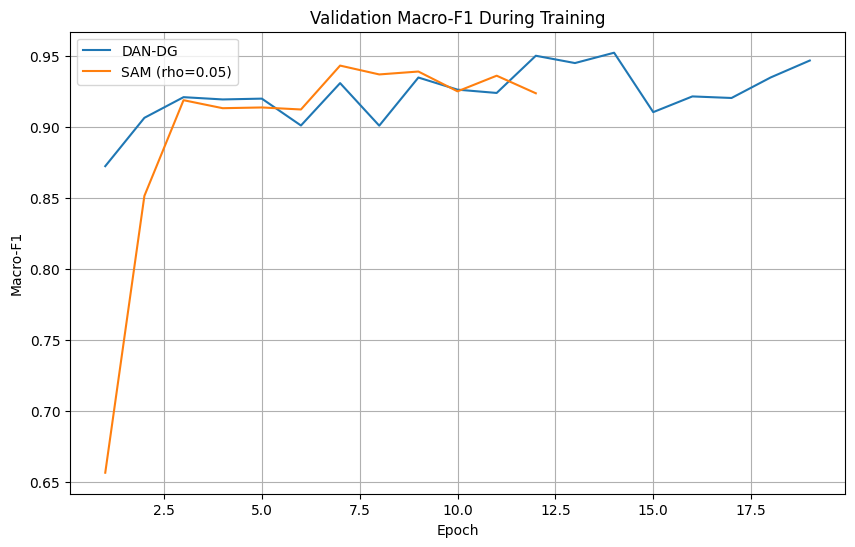

              precision    recall  f1-score      support
0              0.763636  0.435233  0.554455   772.000000
1              0.537666  0.983784  0.695320   740.000000
2              0.938811  0.713147  0.810566   753.000000
3              0.982935  0.947368  0.964824   608.000000
4              0.747956  0.672794  0.708387   816.000000
5              0.959459  0.887500  0.922078    80.000000
6              0.662722  0.700000  0.680851   160.000000
accuracy       0.740392  0.740392  0.740392     0.740392
macro avg      0.799027  0.762832  0.762355  3929.000000
weighted avg   0.785206  0.740392  0.738176  3929.000000


In [10]:
sketch_dataset = MultiDomainDataset(['sketch'], pacs_root, transform=val_transform)
if len(sketch_dataset) > 0:
    sketch_loader = DataLoader(sketch_dataset, batch_size=64, shuffle=False, num_workers=0)
    
    final_results = []
    
    def evaluate_sketch(model, model_name):
        acc, f1 = evaluate(model, sketch_loader)
        return {'Model': model_name, 'Sketch_Acc': acc, 'Sketch_F1': f1}
        
    if os.path.exists(erm_checkpoint_path):
        erm_res = evaluate_sketch(erm_model, 'ERM')
        final_results.append(erm_res)
        
    dandg_res = evaluate_sketch(dandg_model, 'DAN-DG')
    final_results.append(dandg_res)
    
    sam_res = evaluate_sketch(sam_model, 'SAM (rho=0.05)')
    final_results.append(sam_res)
    
    final_df = pd.DataFrame(final_results)
    
    if os.path.exists(erm_checkpoint_path):
        erm_f1 = erm_res['Sketch_F1']
        final_df['Delta_F1_from_ERM'] = final_df['Sketch_F1'] - erm_f1
        
    print(final_df)
    final_df.to_csv('results/task3_comparison.csv', index=False)
    
    plt.figure(figsize=(10, 6))
    plt.plot([h['epoch'] for h in dandg_history], [h['mean_f1'] for h in dandg_history], label='DAN-DG')
    plt.plot([h['epoch'] for h in sam_history], [h['mean_f1'] for h in sam_history], label='SAM (rho=0.05)')
    plt.title('Validation Macro-F1 During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Macro-F1')
    plt.legend()
    plt.grid(True)
    plt.savefig('figures/task3_training_curves.png')
    plt.show()
    
    sam_model.eval()
    sam_model.apply(set_bn_eval)
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels, _ in sketch_loader:
            imgs = imgs.to(device)
            outputs = sam_model(imgs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    from sklearn.metrics import classification_report
    report = classification_report(all_labels, all_preds, output_dict=True)
    class_df = pd.DataFrame(report).transpose()
    print(class_df)
    class_df.to_csv('results/task3_per_class_sketch.csv')
else:
    print("Target dataset (Sketch) not found.")

## 🧠 Analysis

**1. Source-Domain Separability:**
DAN-DG reduces source-domain separability from 0.890 (ERM) to 0.808. A 3-way logistic regression distinguishing Photo, Art Painting, and Cartoon features drops from ~89% to ~81% accuracy, meaning the source domains' features become harder to tell apart. This aligns with the theoretical motivation: pairwise MMD across source domains pushes the model to learn representations where Photo, Art Painting, and Cartoon look more similar. SAM's separability falls in between at 0.827 — it wasn't designed to minimize domain discrepancy, so any separability reduction is a side effect of seeking flatter minima rather than a direct optimization target.

**2. Sharpness Proxy:**
The sharpness proxy Δ_sharp decreases consistently: ERM has the sharpest minimum (0.379), DAN-DG is intermediate (0.223), and SAM achieves the flattest (0.154). SAM is doing exactly what it was designed to do — finding parameter neighborhoods where the loss doesn't spike under perturbation. The fact that DAN-DG also reduces sharpness (relative to ERM) is interesting. Domain alignment may implicitly discourage sharp solutions because a sharp minimum that works for one source domain might not work for another, so the optimization naturally gravitates toward flatter regions when forced to satisfy multiple domain objectives.

**3. Target Performance:**
SAM (ρ=0.05) achieves the best Sketch accuracy at 78.0%, a +22.7 F1-point improvement over ERM (55.4%). DAN-DG also improves substantially to 72.3% (+16.7 F1 points). Both methods improve dramatically over ERM despite never seeing Sketch data.

Looking at the diagnostics: SAM has the lowest sharpness (0.154) and the highest Sketch accuracy (78.0%), while DAN-DG has the lowest separability (0.808) but only second-best Sketch accuracy (72.3%). This suggests that for this particular shift (Photo/Art/Cartoon → Sketch), **flat minima are more valuable than domain-invariant features.** The per-class Sketch breakdown for SAM reveals uneven performance: Guitar is nearly perfect (96.1%), Elephant is strong (94.9%), but Dog is weak (38.0%) and Person mediocre (44.6% from the class report). These failures likely reflect classes where the Photo-Cartoon-Art features that SAM made robust still don't capture the right cues for sketches.

**4. Controlled Study:**
The SAM ρ sweep shows a cliff-edge behavior. ρ=0.01 and ρ=0.05 both achieve ~94% source validation F1 — nearly identical. But ρ=0.1 collapses to 19.0%. This suggests that there's a critical perturbation radius beyond which the two-step SAM optimization becomes unstable — the adversarial perturbation step overshoots and the subsequent gradient update can't recover. The optimal ρ appears to be somewhere in [0.01, 0.05], with diminishing returns from more aggressive perturbation. In practice, ρ=0.05 achieved the best Sketch accuracy, suggesting that the modest additional flattening from ρ=0.05 (vs 0.01) was beneficial for out-of-distribution generalization without reaching the instability threshold.

**DAN (Task 2, with target) vs DAN-DG (Task 3, without target):**
DAN with unlabeled Sketch access achieved 74.5% Sketch accuracy, while DAN-DG without it reached 72.3% — a 2.2 percentage-point gap. Unlabeled target data helped, but less than one might expect. This makes sense: source-domain alignment already removes much of the stylistic variation (Photo vs Art Painting vs Cartoon), and Sketch shares enough structural properties with these source domains that aligning sources gets you most of the way. However, we should note that this comparison is imperfect — DAN and DAN-DG use different alignment objectives (source-target MMD vs pairwise source MMD) and trained for different durations, so the gap cannot be attributed purely to target access.